In [1]:
# Rebuild QR with circular dots where ONLY QR dots are recolored by ring membership.
# Requirements:
# - Three structures: outer ring, middle ring, and central "beamspot" region.
# - Rings/beamspot recolor only the QR dots that fall within those radial bands.
# - Everything else is subtle grey to keep contrast.

%load_ext autoreload
%autoreload 2


import qrcode
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display

In [47]:
def in_finder(x, y, N, border=4, size=7):
    # three finder squares (including their 1-module separators)
    if x < border+size and y < border+size: return True              # top-left
    if x >= N-(border+size) and y < border+size: return True         # top-right
    if x < border+size and y >= N-(border+size): return True         # bottom-left
    return False

# Helpers
def pixel_center(x, y):
    return x + 0.5, N - (y + 0.5)

def is_on_any_track(px, py):
    vx, vy = px - cx, py - cy
    best = None
    for k, u in enumerate(track_dirs):
        t = vx*u[0] + vy*u[1]
        if t < 0:
            continue
        d_perp = np.hypot(vx - t*u[0], vy - t*u[1])
        if d_perp <= track_halfwidth:
            best = k if best is None else best
    return best  # returns track index or None

In [48]:
# 1) Build QR matrix
qr = qrcode.QRCode(
    version=6,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=1,
    border=4,
)
qr.add_data("https://colliderml.com/")
qr.make(fit=True)
M = np.array(qr.get_matrix(), dtype=bool)
N = M.shape[0]

# 2) Geometry (center in module coordinates)
cx, cy = N / 2.0, N / 2.0

# Choose radii so all 3 structures are clearly visible.
# beamspot radius (filled region), middle ring radius, outer ring radius
r_inner = N * 0.13
r_mid  = N * 0.26
# r_out  = N * 0.62
r_out = N * 0.4
ring_thickness = 1.2  # half-width in module units (thin rings)


In [73]:
# Colors and params
black = (0,0,0)
grey  = (0.7,0.7,0.7)
corner_black = (0.4,0.4,0.4)
layer_dot_r = 0.4  # slightly larger for readability
ring_half = ring_thickness

# Tracks params
num_tracks = 8
track_halfwidth = 0.70
track_thetas = np.random.uniform(0, 360, num_tracks)  # degrees (random)
cmap = plt.get_cmap('rainbow')
track_colors = [cmap(i/(num_tracks-1))[:3] for i in range(num_tracks)]
track_dirs = [np.array([np.cos(np.deg2rad(th)), np.sin(np.deg2rad(th))]) for th in track_thetas]


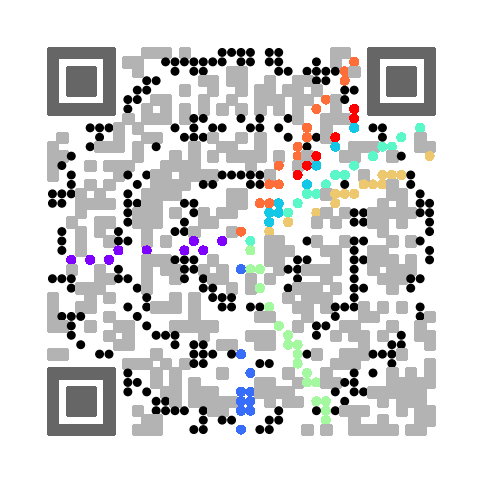

In [74]:
# 3) Helpers + rendering (DRY) with rainbow tracks
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(0, N); ax.set_ylim(0, N); ax.set_aspect("equal"); ax.axis("off")

for y in range(N):
    for x in range(N):
        if not M[y, x]:
            continue

        # Keep finders solid squares
        if in_finder(x, y, N):
            ax.add_patch(patches.Rectangle((x, N-(y+1)), 1, 1, facecolor=corner_black, edgecolor=corner_black, antialiased=False))
            continue

        px, py = pixel_center(x, y)
        r = np.hypot(px - cx, py - cy)

        # 1) Tracks (take precedence)
        tidx = is_on_any_track(px, py)
        if tidx is not None:
            c = track_colors[tidx]
            ax.add_patch(patches.Circle((px, py), layer_dot_r, facecolor=c, edgecolor=c, antialiased=False))
            continue

        # 2) Rings
        if abs(r - r_inner) <= ring_half:
            c = black
            ax.add_patch(patches.Circle((px, py), layer_dot_r, facecolor=c, edgecolor=c, antialiased=True))
        elif abs(r - r_mid) <= ring_half:
            c = black
            ax.add_patch(patches.Circle((px, py), layer_dot_r, facecolor=c, edgecolor=c, antialiased=True))
        elif abs(r - r_out) <= ring_half:
            c = black
            ax.add_patch(patches.Circle((px, py), layer_dot_r, facecolor=c, edgecolor=c, antialiased=True))
        else:
            # 3) Rest as crisp squares (higher contrast than grey dots)
            ax.add_patch(patches.Rectangle((x, N-(y+1)), 1, 1, facecolor=grey, edgecolor=grey, antialiased=False))

    # plt.savefig("qr_lhc_tracks.png", dpi=300, bbox_inches="tight", pad_inches=0)